# Classifying daily performance of US solar plants

**Data:** Sandia National Laboratories, *Extreme Weather Impacts on Utility-scale Photovoltaic Plant Performance* (one row per plant per day).

**Goal:** predict whether a plant-day has **Low**, **Medium** or **High** performance ratio (`PR`) from site, weather and O&M ticket attributes.

In [4]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve

SEED = 42
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.3f}".format)
CLASSES = ["Low", "Medium", "High"]
def load(path):
    return pd.read_csv(path, quotechar="'", na_values="?", parse_dates=["Date"], low_memory=False)

train, test = load("train.csv"), load("test.csv")

## 2. Preprocessing: imputation and normalization

Everything is fitted on `train.csv` only and then applied to both files.

- **Imputation:** a missing numeric value gets the training median; a missing categorical value becomes its own `None` category.
- **Normalization:** every attribute is min-max scaled to 0 – 1.

In [5]:
class_codes = {c: i for i, c in enumerate(CLASSES)}
y_train, y_test = train.PR_class.map(class_codes).rename("class"), test.PR_class.map(class_codes).rename("class")

def attributes(data):
    return data.drop(columns=["randid", "Date", "PR_class"]).assign(month=data.Date.dt.month)

A_train, A_test = attributes(train), attributes(test)
categorical = A_train.select_dtypes(exclude="number").columns
A_train[categorical], A_test[categorical] = A_train[categorical].fillna("None"), A_test[categorical].fillna("None")
categories = {c: sorted(A_train[c].unique()) for c in categorical}

def encode(data):
    return data.assign(**{c: pd.Categorical(data[c], categories[c]).codes for c in categorical})

imputer = SimpleImputer(strategy="median").fit(encode(A_train))
scaler = MinMaxScaler().fit(imputer.transform(encode(A_train)))

def prepare(data):
    data = encode(data)
    return pd.DataFrame(scaler.transform(imputer.transform(data)), columns=data.columns, index=data.index)

X_train, X_test = prepare(A_train), prepare(A_test)
print(X_train.shape, X_test.shape)

(39952, 36) (9988, 36)


## 3. Attribute selection: 4 Weka algorithms + 1 manual set + all attributes as a baseline

| Set | Weka attribute evaluator | Weka search method | How it works |
|---|---|---|---|
| InfoGain | `InfoGainAttributeEval` | `Ranker` (numToSelect = 10) | H(class) − H(class given attribute) |
| GainRatio | `GainRatioAttributeEval` | `Ranker` (numToSelect = 10) | InfoGain / H(attribute) |
| CFS | `CfsSubsetEval` (locallyPredictive = False) | `GreedyStepwise` (forward) | subset merit: high correlation with the class, low correlation between attributes |
| Wrapper | `WrapperSubsetEval` (decision tree in place of J48, 5 folds) | `GreedyStepwise` (forward) | adds the attribute that most improves cross-validated accuracy, stops when nothing improves |
| Manual | – | – | chosen by us |
| All | – | – | baseline, no selection |

As in Weka, the three entropy-based evaluators first discretize numeric attributes with the supervised Fayyad & Irani MDL method (Weka's `Discretize` filter). The cut points are learned on the training set and are used for attribute selection only.

The train and test data of every set are saved to `attribute_sets/` (numeric attributes imputed and normalized, categorical attributes with their labels).

In [10]:
def entropy(counts):
    p = counts / counts.sum(axis=-1, keepdims=True)
    return -(p * np.log2(p, out=np.zeros_like(p), where=p > 0)).sum(axis=-1)

def mdl_cut_points(x, y):
    order = np.argsort(x)
    x, onehot = x[order], np.eye(len(CLASSES))[y[order]]

    def split(lo, hi):
        n = hi - lo
        total = onehot[lo:hi].sum(axis=0)
        left = onehot[lo:hi].cumsum(axis=0)[:-1]
        right = total - left
        n_left = np.arange(1, n)
        h_left, h_right = entropy(left), entropy(right)
        h_split = (n_left * h_left + (n - n_left) * h_right) / n
        h_split[x[lo + 1:hi] == x[lo:hi - 1]] = np.inf
        i = h_split.argmin()
        if np.isinf(h_split[i]):
            return []
        h = entropy(total)
        k, k_left, k_right = (total > 0).sum(), (left[i] > 0).sum(), (right[i] > 0).sum()
        delta = np.log2(3 ** k - 2) - (k * h - k_left * h_left[i] - k_right * h_right[i])
        if h - h_split[i] <= (np.log2(n - 1) + delta) / n:
            return []
        cut = lo + i + 1
        return split(lo, cut) + [(x[cut - 1] + x[cut]) / 2] + split(cut, hi)

    return split(0, len(x))

numeric = X_train.columns.difference(categorical)
cut_points = {c: mdl_cut_points(X_train[c].to_numpy(), y_train.to_numpy()) for c in numeric}

D_train = X_train.copy()
for c in numeric:
    D_train[c] = np.digitize(X_train[c], cut_points[c])


In [7]:
def info_gain(a, b):
    table = pd.crosstab(a, b).to_numpy()
    return entropy(table.sum(axis=0)) - (table.sum(axis=1) / table.sum()) @ entropy(table)

def gain_ratio(a, b):
    return info_gain(a, b) / (entropy(a.value_counts().to_numpy()) or 1)

def symmetrical_uncertainty(a, b):
    return 2 * info_gain(a, b) / ((entropy(a.value_counts().to_numpy()) + entropy(b.value_counts().to_numpy())) or 1)

def cfs(D, y):
    class_corr = D.apply(symmetrical_uncertainty, b=y)
    attr_corr = D.apply(lambda a: D.apply(symmetrical_uncertainty, b=a))

    def merit(cols):
        corr = attr_corr.loc[cols, cols].to_numpy()
        between = corr.sum() - np.trace(corr)
        return class_corr[cols].sum() / np.sqrt(len(cols) + between)

    chosen, best = [], 0
    while True:
        candidates = {c: merit(chosen + [c]) for c in D.columns.difference(chosen)}
        winner = max(candidates, key=candidates.get)
        if candidates[winner] <= best:
            return chosen
        chosen, best = chosen + [winner], candidates[winner]

K = 10
ranking = pd.DataFrame({
    "InfoGain": D_train.apply(info_gain, b=y_train),
    "GainRatio": D_train.apply(gain_ratio, b=y_train),
})
ranking.sort_values("InfoGain", ascending=False)

,InfoGain,GainRatio
NOAAClimRegion,0.118,0.052
low_irradiation,0.116,0.130
month,0.104,0.033
plant_age_months,0.099,0.022
TempZone,0.098,0.060
wind_speed_mean,0.071,0.027
nearest_rain,0.070,0.026
nearest_flood,0.054,0.025
cumulative_snow_mm,0.038,0.039
nearest_hurricane,0.036,0.036


In [8]:
tree = DecisionTreeClassifier(criterion="entropy", min_samples_leaf=20, random_state=SEED)
wrapper = SequentialFeatureSelector(tree, n_features_to_select="auto", tol=0, cv=5, n_jobs=-1).fit(X_train, y_train)

attribute_sets = {
    "InfoGain": list(ranking.InfoGain.nlargest(K).index),
    "GainRatio": list(ranking.GainRatio.nlargest(K).index),
    "CFS": cfs(D_train, y_train),
    "Wrapper": list(wrapper.get_feature_names_out()),
    "Manual": [
        "NOAAClimRegion", "TempZone", "HumidZone", "bin_PlantSize_kW", "plant_age_months", "month",
        "low_irradiation", "total_daily_snow_mm", "cumulative_snow_mm", "rain_value_mm", "wind_speed_mean",
    ],
    "All": list(X_train.columns),
}

pd.DataFrame({name: pd.Series(cols) for name, cols in attribute_sets.items() if name != "All"}).fillna("")

,InfoGain,GainRatio,CFS,Wrapper,Manual
0,NOAAClimRegion,lightning,low_irradiation,NOAAClimRegion,NOAAClimRegion
1,low_irradiation,HurricanePrep,NOAAClimRegion,TempZone,TempZone
2,month,low_irradiation,month,bin_PlantSize_kW,HumidZone
3,plant_age_months,snow_value_mm,TempZone,plant_age_months,bin_PlantSize_kW
4,TempZone,storm_affected_assets,total_daily_snow_mm,snow_bin_ticket_minutes,plant_age_months
5,wind_speed_mean,storm_active_tickets,wind_speed_mean,snow_affected_assets,month
6,nearest_rain,storm_bin_ticket_minutes,,total_daily_snow_mm,low_irradiation
7,nearest_flood,storm_production_level,,low_irradiation,total_daily_snow_mm
8,cumulative_snow_mm,total_daily_snow_mm,,cumulative_snow_mm,cumulative_snow_mm
9,nearest_hurricane,duration_minutes_flood,,hurr_affected_assets,rain_value_mm


In [9]:
Path("attribute_sets").mkdir(exist_ok=True)
labelled = {
    "train": X_train.assign(**A_train[categorical], PR_class=train.PR_class),
    "test": X_test.assign(**A_test[categorical], PR_class=test.PR_class),
}

saved = []
for name, cols in attribute_sets.items():
    for part, data in labelled.items():
        path = f"attribute_sets/{name}_{part}.csv"
        data[cols + ["PR_class"]].to_csv(path, index=False, quotechar="'")
        saved.append({"file": path, "rows": len(data), "attributes": len(cols)})
pd.DataFrame(saved).set_index("file")

,rows,attributes
file,,
attribute_sets/InfoGain_train.csv,39952,10
attribute_sets/InfoGain_test.csv,9988,10
attribute_sets/GainRatio_train.csv,39952,10
attribute_sets/GainRatio_test.csv,9988,10
attribute_sets/CFS_train.csv,39952,6
attribute_sets/CFS_test.csv,9988,6
attribute_sets/Wrapper_train.csv,39952,17
attribute_sets/Wrapper_test.csv,9988,17
attribute_sets/Manual_train.csv,39952,11


## 4. Train and test 6 attribute sets × 4 classifiers = 24 models

5 attribute selections × 4 classifiers = 20 models, plus 4 baseline models on all attributes.

| Classifier | Weka equivalent |
|---|---|
| DecisionTree | `J48` (closest match: scikit-learn grows a CART tree, here with the entropy criterion) |
| RandomForest | `RandomForest` |
| NaiveBayes | `NaiveBayes` |
| Logistic | `Logistic` |

In [11]:
classifiers = {
    "DecisionTree": DecisionTreeClassifier(criterion="entropy", min_samples_leaf=20, random_state=SEED),
    "RandomForest": RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=SEED),
    "NaiveBayes": GaussianNB(),
    "Logistic": LogisticRegression(max_iter=1000),
}

support = np.bincount(y_test)
weights = support / support.sum()

rows, probabilities = [], {}
for set_name, cols in attribute_sets.items():
    for clf_name, clf in classifiers.items():
        prob = clf.fit(X_train[cols], y_train).predict_proba(X_test[cols])
        cm = confusion_matrix(y_test, prob.argmax(axis=1))
        tp = np.diag(cm)
        fp = cm.sum(axis=0) - tp
        tp_rate = tp / support
        fp_rate = fp / (support.sum() - support)
        probabilities[set_name, clf_name] = prob
        rows.append({
            "attributes": set_name,
            "classifier": clf_name,
            "accuracy": tp.sum() / support.sum(),
            **{f"TP_{c}": r for c, r in zip(CLASSES, tp_rate)},
            **{f"FP_{c}": r for c, r in zip(CLASSES, fp_rate)},
            "TP_rate": tp_rate @ weights,
            "FP_rate": fp_rate @ weights,
            "AUC": roc_auc_score(y_test, prob, multi_class="ovr", average="weighted"),
        })

results = pd.DataFrame(rows)
results.sort_values("AUC", ascending=False).reset_index(drop=True)

,attributes,classifier,accuracy,TP_Low,TP_Medium,TP_High,FP_Low,FP_Medium,FP_High,TP_rate,FP_rate,AUC
0,All,RandomForest,0.773,0.792,0.752,0.773,0.091,0.123,0.126,0.773,0.114,0.914
1,Wrapper,RandomForest,0.754,0.787,0.723,0.754,0.102,0.129,0.138,0.754,0.123,0.905
2,InfoGain,RandomForest,0.754,0.769,0.752,0.740,0.103,0.137,0.130,0.754,0.123,0.903
3,All,DecisionTree,0.740,0.777,0.721,0.724,0.120,0.132,0.138,0.740,0.130,0.895
4,Wrapper,DecisionTree,0.739,0.761,0.721,0.734,0.111,0.133,0.149,0.739,0.131,0.895
5,Manual,RandomForest,0.731,0.766,0.699,0.727,0.113,0.145,0.146,0.731,0.135,0.891
6,InfoGain,DecisionTree,0.732,0.770,0.713,0.714,0.129,0.131,0.142,0.732,0.134,0.887
7,Manual,DecisionTree,0.716,0.748,0.693,0.708,0.123,0.141,0.161,0.716,0.142,0.879
8,CFS,DecisionTree,0.639,0.640,0.645,0.633,0.148,0.182,0.211,0.639,0.180,0.817
9,CFS,RandomForest,0.603,0.614,0.595,0.601,0.166,0.192,0.237,0.603,0.198,0.791


## 5. Performance comparison

`TP_<class>` / `FP_<class>` are the per-class rates. `TP_rate`, `FP_rate` and `AUC` are averages weighted by class size, as in Weka's "Weighted Avg." row (weighted TP rate equals accuracy).

In [12]:
for metric in ["accuracy", "TP_Low", "TP_Medium", "TP_High", "FP_rate", "AUC"]:
    table = results.pivot(index="attributes", columns="classifier", values=metric).loc[list(attribute_sets), list(classifiers)]
    display(table.style.format("{:.3f}").background_gradient(cmap="Blues", axis=None).set_caption(metric))

classifier,DecisionTree,RandomForest,NaiveBayes,Logistic
attributes,,,,
InfoGain,0.732,0.754,0.447,0.526
GainRatio,0.491,0.490,0.361,0.489
CFS,0.639,0.603,0.420,0.525
Wrapper,0.739,0.754,0.453,0.538
Manual,0.716,0.731,0.423,0.524
All,0.740,0.773,0.364,0.548


classifier,DecisionTree,RandomForest,NaiveBayes,Logistic
attributes,,,,
InfoGain,0.770,0.769,0.197,0.561
GainRatio,0.568,0.565,0.093,0.569
CFS,0.640,0.614,0.079,0.553
Wrapper,0.761,0.787,0.122,0.570
Manual,0.748,0.766,0.120,0.550
All,0.777,0.792,0.119,0.574


classifier,DecisionTree,RandomForest,NaiveBayes,Logistic
attributes,,,,
InfoGain,0.713,0.752,0.881,0.711
GainRatio,0.894,0.895,0.000,0.897
CFS,0.645,0.595,0.877,0.731
Wrapper,0.721,0.723,0.792,0.693
Manual,0.693,0.699,0.867,0.724
All,0.721,0.752,0.006,0.713


classifier,DecisionTree,RandomForest,NaiveBayes,Logistic
attributes,,,,
InfoGain,0.714,0.740,0.262,0.304
GainRatio,0.012,0.011,0.989,0.002
CFS,0.633,0.601,0.303,0.291
Wrapper,0.734,0.754,0.446,0.351
Manual,0.708,0.727,0.283,0.299
All,0.724,0.773,0.965,0.358


classifier,DecisionTree,RandomForest,NaiveBayes,Logistic
attributes,,,,
InfoGain,0.134,0.123,0.277,0.237
GainRatio,0.254,0.255,0.320,0.256
CFS,0.180,0.198,0.290,0.238
Wrapper,0.131,0.123,0.273,0.231
Manual,0.142,0.135,0.288,0.238
All,0.130,0.114,0.318,0.226


classifier,DecisionTree,RandomForest,NaiveBayes,Logistic
attributes,,,,
InfoGain,0.887,0.903,0.688,0.686
GainRatio,0.638,0.637,0.619,0.636
CFS,0.817,0.791,0.682,0.676
Wrapper,0.895,0.905,0.689,0.702
Manual,0.879,0.891,0.678,0.685
All,0.895,0.914,0.682,0.711


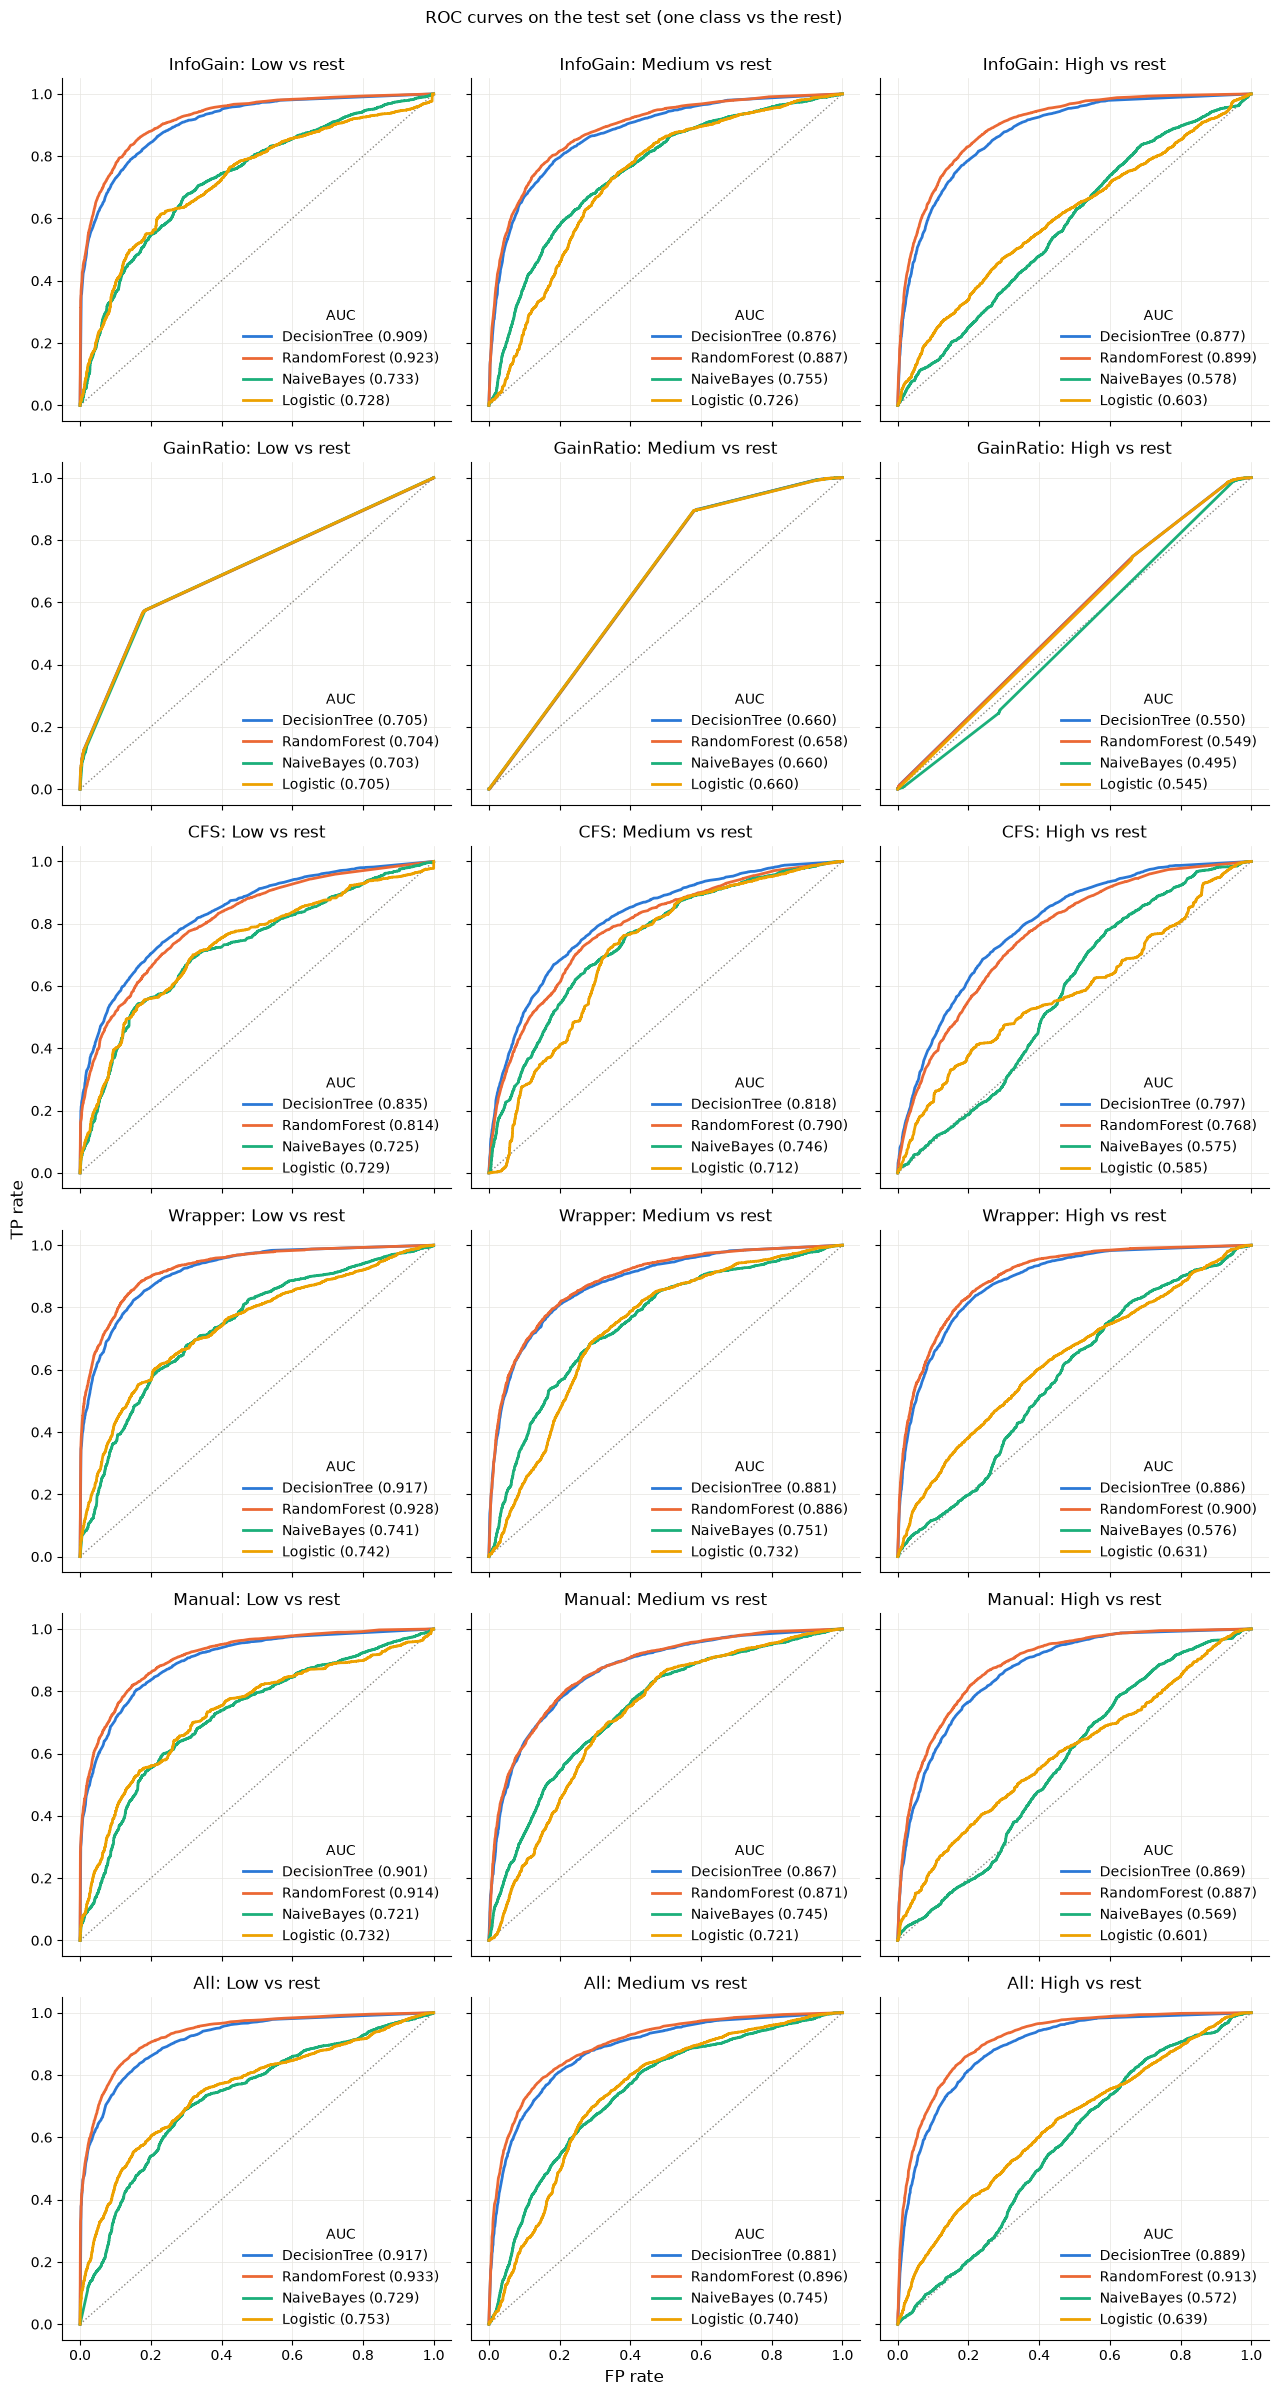

In [13]:
colors = dict(zip(classifiers, ["#2a78d6", "#eb6834", "#1baf7a", "#eda100"]))

fig, axes = plt.subplots(len(attribute_sets), 3, figsize=(13, 24), sharex=True, sharey=True)
for row, set_name in zip(axes, attribute_sets):
    for i, (ax, class_name) in enumerate(zip(row, CLASSES)):
        ax.plot([0, 1], [0, 1], color="#898781", linestyle=":", linewidth=1)
        for clf_name in classifiers:
            prob = probabilities[set_name, clf_name][:, i]
            fpr, tpr, _ = roc_curve(y_test == i, prob)
            ax.plot(fpr, tpr, color=colors[clf_name], linewidth=2, label=f"{clf_name} ({roc_auc_score(y_test == i, prob):.3f})")
        ax.set_title(f"{set_name}: {class_name} vs rest")
        ax.legend(title="AUC", loc="lower right", frameon=False)
        ax.spines[["top", "right"]].set_visible(False)
        ax.grid(color="#e6e5e0", linewidth=0.5)
fig.supxlabel("FP rate")
fig.supylabel("TP rate")
fig.suptitle("ROC curves on the test set (one class vs the rest)", y=1)
plt.tight_layout()
plt.show()

## 6. Best model

In [15]:
best = results.sort_values("AUC", ascending=False).iloc[0]
best

attributes             All
classifier    RandomForest
accuracy             0.773
TP_Low               0.792
TP_Medium            0.752
TP_High              0.773
FP_Low               0.091
FP_Medium            0.123
FP_High              0.126
TP_rate              0.773
FP_rate              0.114
AUC                  0.914
Name: 21, dtype: object

In [16]:
prob = probabilities[best.attributes, best.classifier]
pd.DataFrame(
    confusion_matrix(y_test, prob.argmax(axis=1)),
    index=[f"actual {c}" for c in CLASSES],
    columns=[f"predicted {c}" for c in CLASSES],
)

,predicted Low,predicted Medium,predicted High
actual Low,2638,351,340
actual Medium,322,2505,502
actual High,286,469,2575


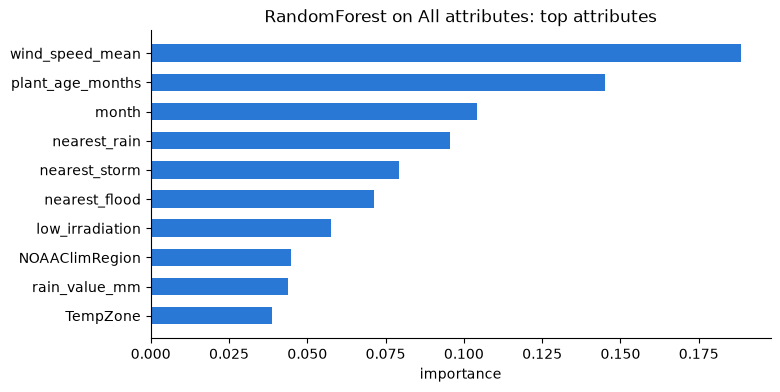

In [17]:
cols = attribute_sets[best.attributes]
model = classifiers[best.classifier].fit(X_train[cols], y_train)
importance = pd.Series(model.feature_importances_, index=cols).nlargest(10).sort_values()

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(importance.index, importance.values, color="#2a78d6", height=0.6)
ax.set(xlabel="importance", title=f"{best.classifier} on {best.attributes} attributes: top attributes")
ax.spines[["top", "right"]].set_visible(False)
plt.show()